In [2]:
!pip install pandas
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 3.8 MB/s eta 0:00:00a 0:00:01


<center>

# Mathematical Model

</center>

Sets and parameters:
- $I$: set of demand points
- $J$: set of candidate facility points
- $p$: Number of facilities
- $w_i$: Weight of demand point i
- $d_{ij}$: distance between damand point i and candidate facility point j


Decision variables:
- $x_j$: 1 if a facility is loacated at candidate facility, 0 otherwise, where $j \in J$
- $y_{ij}$: 1 if demand point $i \in I$ is assigned to facility $j \in J$



$$
\begin{align}
    \min \quad & \sum_{i \in I}\sum_{j \in J} w_id_{ij}y_{ij}  \\
    \text{s.t.} \quad 
    & \sum_{j \in J} x_j = p \\
    & \sum_{j \in J} y_{ij} = 1 \quad \forall i \in I\\
    & y_{ij} \le x_j \quad \forall i \in I, \forall j \in J\\
    & x_j \in \{0,1\}, y_{ij} \in \{0,1\}
\end{align}
$$

<center>

# 서구 인구수 7 : 유동인구 3 가중치

</center>

[INFO] Load Seogu grid ...
[INFO] Load transit points (bus/subway) ...
[INFO] Load current & candidate lockers ...
[INFO] |I|=458, |J|=101, p=6
[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
MIPGap  0.01

Optimize a model with 46717 rows, 46359 columns and 138875 nonzeros
Model fingerprint: 0x0708cc93
Variable types: 0 continuous, 46359 integer (46359 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-02, 1e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 6e+00]
Found heuristic solution: objective 223573.17222
Presolve time: 0.11s
Presolved: 46717 rows, 46359 columns, 138875 nonzeros
Variable type

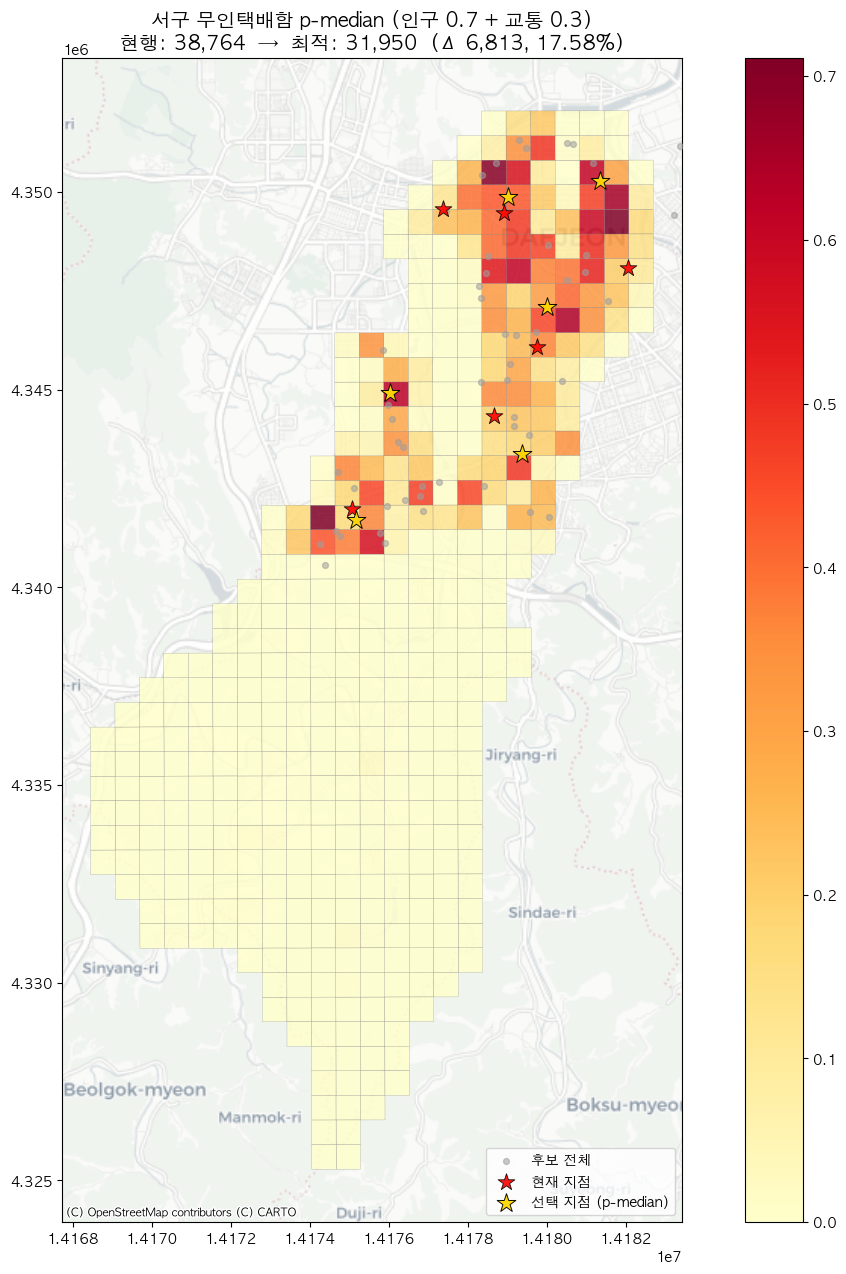

In [15]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import gurobipy as gp
from gurobipy import GRB
import warnings
from matplotlib import font_manager, rc

warnings.filterwarnings("ignore", category=UserWarning)

input_shp = r"/Users/anjunho/Desktop/물류 데이터 공모전/인구밀도_서구.shp"
csv_path = r"/Users/anjunho/Desktop/물류 데이터 공모전/preprocessing ver7.csv"
current_lockers = r"/Users/anjunho/Desktop/물류 데이터 공모전/무인택배함.csv"
new_lockers_path = r"/Users/anjunho/Desktop/물류 데이터 공모전/finaldestination.csv"

# ===== 한글 폰트 설정 =====
rc('font', family='AppleGothic') # mac 버전/
plt.rcParams['axes.unicode_minus'] = False

# 가중치: 인구 0.7, 교통(버스+지하철) 0.3
POP_W = 0.7
TRANSIT_W = 0.3

# 최적화 파라미터
TIME_LIMIT = 300   # 초
MIP_GAP    = 0.01  # 1%

# ======================================================
# 2) 데이터 로드 & 수요 w_i 구성
# ======================================================
print("[INFO] Load Seogu grid ...")
gdf = gpd.read_file(input_shp)
gdf = gdf[gdf.geometry.notnull() & gdf.geometry.is_valid].copy()
if (not gdf.crs) or (not gdf.crs.is_projected):
    gdf = gdf.to_crs(5179)  # GRS80 / UTM-K (m 단위 근사)

# 인구 컬럼: 'val' 가정
pop_col = "val"
if pop_col not in gdf.columns:
    raise ValueError(f"'val' 컬럼이 필요합니다. 현재 컬럼: {list(gdf.columns)}")
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce").fillna(0)

print("[INFO] Load transit points (bus/subway) ...")
df_pts = pd.read_csv(csv_path)
df_pts = df_pts[df_pts["시군구명"].str.contains("서구", na=False)].copy()
gdf_pts = gpd.GeoDataFrame(
    df_pts, geometry=gpd.points_from_xy(df_pts["경도"], df_pts["위도"]), crs=4326
).to_crs(5179)

# 격자별 버스/지하철 평균 이용량 집계
joined = gpd.sjoin(gdf_pts, gdf, how="left", predicate="intersects")
joined["월 평균 승하차 인원"] = pd.to_numeric(joined["월 평균 승하차 인원"], errors="coerce").fillna(0)

bus_mean = joined[joined["시설 종류"]=="버스"]   .groupby("index_right")["월 평균 승하차 인원"].mean()
sub_mean = joined[joined["시설 종류"]=="지하철"].groupby("index_right")["월 평균 승하차 인원"].mean()

gdf["bus_mean"] = gdf.index.map(bus_mean).fillna(0)
gdf["sub_mean"] = gdf.index.map(sub_mean).fillna(0)

# Min-Max 정규화
def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    vmin, vmax = s.min(), s.max()
    if vmax - vmin < 1e-12:
        return pd.Series(0.0, index=s.index)
    return (s - vmin) / (vmax - vmin)

# 정규화 및 w_i 계산: w = 0.7*pop_n + 0.3*transit_n (transit = bus/sub 평균)
gdf["pop_n"]     = minmax(gdf[pop_col])
gdf["bus_n"]     = minmax(gdf["bus_mean"])
gdf["sub_n"]     = minmax(gdf["sub_mean"])
gdf["transit_n"] = 0.5*(gdf["bus_n"] + gdf["sub_n"])
gdf["w"]         = POP_W*gdf["pop_n"] + TRANSIT_W*gdf["transit_n"]

# 수요점 = 격자 중심
gdf_cent = gdf.copy()
gdf_cent["geometry"] = gdf_cent.geometry.centroid  # 5179 기준
I = list(range(len(gdf_cent)))

# ======================================================
# 3) 후보 집합 J, p 설정 (현재 개수 유지, 새 후보만 선택)
# ======================================================
print("[INFO] Load current & candidate lockers ...")
df_cur = pd.read_csv(current_lockers, encoding="utf-8-sig")
gdf_cur = gpd.GeoDataFrame(
    df_cur, geometry=gpd.points_from_xy(df_cur["경도"], df_cur["위도"]), crs=4326
).to_crs(5179)

df_new = pd.read_csv(new_lockers_path, encoding="utf-8-sig")
gdf_cand = gpd.GeoDataFrame(
    df_new, geometry=gpd.points_from_xy(df_new["경도"], df_new["위도"]), crs=4326
).to_crs(5179)

# 설치 개수 p = 현재 지점 수
p = len(gdf_cur)
J = list(range(len(gdf_cand)))
print(f"[INFO] |I|={len(I)}, |J|={len(J)}, p={p}")

# ======================================================
# 4) 거리행렬 (5179: m 근사)
# ======================================================
ci = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])
cj = np.array([(pt.x, pt.y) for pt in gdf_cand.geometry])
dmat = np.sqrt(((ci[:,None,:] - cj[None,:,:])**2).sum(axis=2))  # |I| x |J|

# ======================================================
# 5) p-median 최적화
# ======================================================
print("[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...")
w = gdf_cent["w"].to_dict()

m = gp.Model("p_median_relocation")
x = m.addVars(J, vtype=GRB.BINARY, name="x")                        # 후보 설치 여부
y = m.addVars(((i,j) for i in I for j in J), vtype=GRB.BINARY, name="y")  # i→j 할당

# 설치 개수 고정
m.addConstr(gp.quicksum(x[j] for j in J) == p)
# 각 수요 i는 정확히 1곳에 할당
for i in I:
    m.addConstr(gp.quicksum(y[i,j] for j in J) == 1)
# 설치된 곳에만 할당
for i in I:
    for j in J:
        m.addConstr(y[i,j] <= x[j])

# 목적: Σ_i Σ_j w_i * d_ij * y_ij 최소화
m.setObjective(gp.quicksum(w[i]*dmat[i,j]*y[i,j] for i in I for j in J), GRB.MINIMIZE)

m.Params.OutputFlag = 1
m.Params.TimeLimit  = TIME_LIMIT
m.Params.MIPGap     = MIP_GAP
m.optimize()

open_sites = [j for j in J if x[j].X > 0.5]
assign     = {i: max(J, key=lambda j: y[i,j].X) for i in I}
print(f"[RESULT] Open sites (count={len(open_sites)}): {open_sites}")

# ======================================================
# 6) 목적함수 비교: 현행 vs 최적
# ======================================================
# 현행 설치지 집합(현재 무인택배함)과 최적 설치지(새 후보 중 선택)에 대해
# Σ_i w_i * min_j d(i, j) 값을 각각 계산
print("\n=== 목적함수 비교 (p-median; Σ_i w_i * d(i,시설)) ===")
ci_xy = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])                  # |I| x 2
cj_cur_xy = np.array([(pt.x, pt.y) for pt in gdf_cur.geometry])               # |J_cur| x 2
cj_opt_xy = np.array([(pt.x, pt.y) for pt in gdf_cand.iloc[open_sites].geometry])  # |p| x 2

dmat_cur = np.sqrt(((ci_xy[:,None,:] - cj_cur_xy[None,:,:])**2).sum(axis=2)) if len(cj_cur_xy)>0 else np.zeros((len(ci_xy),1))
dmat_opt = np.sqrt(((ci_xy[:,None,:] - cj_opt_xy[None,:,:])**2).sum(axis=2)) if len(cj_opt_xy)>0 else np.zeros((len(ci_xy),1))

min_d_cur = dmat_cur.min(axis=1) if dmat_cur.shape[1] > 0 else np.zeros(len(ci_xy))
min_d_opt = dmat_opt.min(axis=1) if dmat_opt.shape[1] > 0 else np.zeros(len(ci_xy))

w_vec = gdf_cent["w"].to_numpy()
obj_cur = float(np.dot(w_vec, min_d_cur))
obj_opt = float(np.dot(w_vec, min_d_opt))
improve_abs = obj_cur - obj_opt
improve_pct = (improve_abs / obj_cur * 100.0) if obj_cur > 1e-12 else 0.0

print(f"현행 설치(현재 무인택배함)  : {obj_cur:,.2f}")
print(f"최적 해(새 후보 중 선택)   : {obj_opt:,.2f}")
print(f"차이(현행-최적)            : {improve_abs:,.2f}")
print(f"개선율(%)                  : {improve_pct:,.2f}%")

# ======================================================
# 7) 시각화 & 저장 (서구로 자동 확대)
# ======================================================
print("[INFO] Plot ...")
gdf_3857  = gdf.to_crs(3857)
cand_3857 = gdf_cand.to_crs(3857)
cur_3857  = gdf_cur.to_crs(3857)

fig, ax = plt.subplots(figsize=(13, 13))

# 배경: w 코로플레스 (인구0.7+교통0.3)
gdf_3857.plot(ax=ax, column="w", cmap="YlOrRd", legend=True,
              edgecolor="gray", linewidth=0.2, alpha=0.85)

# 전체 후보(연회색 점)
cand_3857.plot(ax=ax, color="#9e9e9e", markersize=18, alpha=0.55, label="후보 전체", zorder=6)

# 현재 지점(빨간★)
cur_3857.plot(ax=ax, marker="*", color="red", edgecolor="black",
              markersize=160, linewidth=0.6, alpha=0.9, label="현재 지점", zorder=8)

# 선택 지점(금색★)
chosen = cand_3857.iloc[open_sites]
chosen.plot(ax=ax, marker="*", color="gold", edgecolor="black",
            markersize=200, linewidth=0.7, alpha=0.95, label="선택 지점 (p-median)", zorder=9)

# ---- 서구 격자 바운딩박스만으로 축 설정(과도한 확대/축소 방지) ----
xmin, ymin, xmax, ymax = gdf_3857.total_bounds
pad_x = (xmax - xmin) * 0.05  # 5% 여백
pad_y = (ymax - ymin) * 0.05
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# 베이스맵
cx.add_basemap(ax, crs=gdf_3857.crs, source=cx.providers.CartoDB.Positron)

ax.set_title(
    f"서구 무인택배함 p-median (인구 0.7 + 교통 0.3)\n"
    f"현행: {obj_cur:,.0f}  →  최적: {obj_opt:,.0f}  (Δ {improve_abs:,.0f}, {improve_pct:,.2f}%)",
    fontsize=14, fontweight="bold"
)
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("seogu_pmedian_pop0p7_transit0p3.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# ======================================================
# Folium: 선택된 "새 후보"만 표시 (OpenStreetMap, 시설명 항상 표시)
# ======================================================
import folium
from IPython.display import display

# 1) 선택된 후보만 추출 → WGS84로 변환
chosen_wgs84 = gdf_cand.iloc[open_sites].to_crs(4326).copy()

# 2) 시설명 컬럼 자동 감지
def pick_name(df):
    for c in ["시설명", "장소", "name", "Name"]:
        if c in df.columns:
            return c
    return None
name_col = pick_name(chosen_wgs84)

# 3) 지도 생성 (OpenStreetMap)
m = folium.Map(location=[37.58, 127.0], tiles="openstreetmap", zoom_start=11)

# 4) 마커 + 이름 라벨 표시
for idx, row in chosen_wgs84.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    lat, lon = row.geometry.y, row.geometry.x
    nm = str(row[name_col]) if name_col and pd.notna(row[name_col]) else f"선택지점 #{idx}"
    
    # 마커 (기본 파란 핀)
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color="blue", icon="info-sign"),
        popup=f"<b>{nm}</b>"
    ).add_to(m)
    
    # 마커 옆 라벨 (DivIcon)
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 11pt;
                color: black;
                background-color: rgba(255,255,255,0.8);
                border-radius: 4px;
                padding: 2px 4px;
                white-space: nowrap;
                ">
                {nm}
            </div>
            """
        )
    ).add_to(m)

# 5) (선택) 선택지의 범위로 화면 자동 맞추기
if len(chosen_wgs84) > 0:
    minx, miny, maxx, maxy = chosen_wgs84.total_bounds
    m.fit_bounds([[miny, minx], [maxy, maxx]])    

# 5) 보기 및 저장
display(m)

<center>

# 서구 인구수 5: 유동인구 5 가중치

</center>

[INFO] Load Seogu grid ...
[INFO] Load transit points (bus/subway) ...
[INFO] Load current & candidate lockers ...
[INFO] |I|=458, |J|=101, p=6
[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
MIPGap  0.01

Optimize a model with 46717 rows, 46359 columns and 138875 nonzeros
Model fingerprint: 0x7ab9c9c4
Variable types: 0 continuous, 46359 integer (46359 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e-02, 8e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 6e+00]
Found heuristic solution: objective 178460.47628
Presolve time: 0.11s
Presolved: 46717 rows, 46359 columns, 138875 nonzeros
Variable type

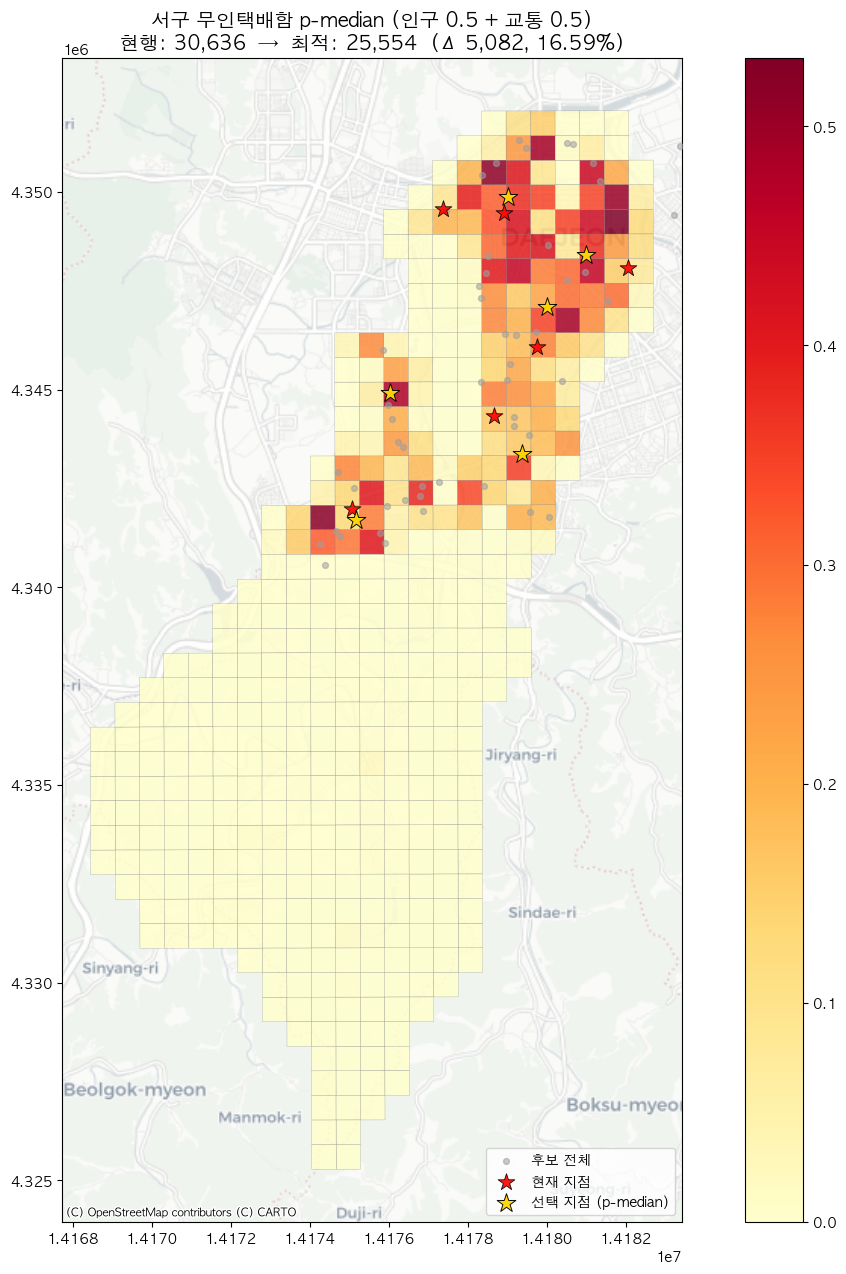

In [17]:
# 가중치: 인구 0.5, 교통(버스+지하철) 0.5
POP_W = 0.5
TRANSIT_W = 0.5

# 최적화 파라미터
TIME_LIMIT = 300   # 초
MIP_GAP    = 0.01  # 1%

# ======================================================
# 2) 데이터 로드 & 수요 w_i 구성
# ======================================================
print("[INFO] Load Seogu grid ...")
gdf = gpd.read_file(input_shp)
gdf = gdf[gdf.geometry.notnull() & gdf.geometry.is_valid].copy()
if (not gdf.crs) or (not gdf.crs.is_projected):
    gdf = gdf.to_crs(5179)  # GRS80 / UTM-K (m 단위 근사)

# 인구 컬럼: 'val' 가정
pop_col = "val"
if pop_col not in gdf.columns:
    raise ValueError(f"'val' 컬럼이 필요합니다. 현재 컬럼: {list(gdf.columns)}")
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce").fillna(0)

print("[INFO] Load transit points (bus/subway) ...")
df_pts = pd.read_csv(csv_path)
df_pts = df_pts[df_pts["시군구명"].str.contains("서구", na=False)].copy()
gdf_pts = gpd.GeoDataFrame(
    df_pts, geometry=gpd.points_from_xy(df_pts["경도"], df_pts["위도"]), crs=4326
).to_crs(5179)

# 격자별 버스/지하철 평균 이용량 집계
joined = gpd.sjoin(gdf_pts, gdf, how="left", predicate="intersects")
joined["월 평균 승하차 인원"] = pd.to_numeric(joined["월 평균 승하차 인원"], errors="coerce").fillna(0)

bus_mean = joined[joined["시설 종류"]=="버스"]   .groupby("index_right")["월 평균 승하차 인원"].mean()
sub_mean = joined[joined["시설 종류"]=="지하철"].groupby("index_right")["월 평균 승하차 인원"].mean()

gdf["bus_mean"] = gdf.index.map(bus_mean).fillna(0)
gdf["sub_mean"] = gdf.index.map(sub_mean).fillna(0)

# Min-Max 정규화
def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    vmin, vmax = s.min(), s.max()
    if vmax - vmin < 1e-12:
        return pd.Series(0.0, index=s.index)
    return (s - vmin) / (vmax - vmin)

# 정규화 및 w_i 계산: w = 0.7*pop_n + 0.3*transit_n (transit = bus/sub 평균)
gdf["pop_n"]     = minmax(gdf[pop_col])
gdf["bus_n"]     = minmax(gdf["bus_mean"])
gdf["sub_n"]     = minmax(gdf["sub_mean"])
gdf["transit_n"] = 0.5*(gdf["bus_n"] + gdf["sub_n"])
gdf["w"]         = POP_W*gdf["pop_n"] + TRANSIT_W*gdf["transit_n"]

# 수요점 = 격자 중심
gdf_cent = gdf.copy()
gdf_cent["geometry"] = gdf_cent.geometry.centroid  # 5179 기준
I = list(range(len(gdf_cent)))

# ======================================================
# 3) 후보 집합 J, p 설정 (현재 개수 유지, 새 후보만 선택)
# ======================================================
print("[INFO] Load current & candidate lockers ...")
df_cur = pd.read_csv(current_lockers, encoding="utf-8-sig")
gdf_cur = gpd.GeoDataFrame(
    df_cur, geometry=gpd.points_from_xy(df_cur["경도"], df_cur["위도"]), crs=4326
).to_crs(5179)

df_new = pd.read_csv(new_lockers_path, encoding="utf-8-sig")
gdf_cand = gpd.GeoDataFrame(
    df_new, geometry=gpd.points_from_xy(df_new["경도"], df_new["위도"]), crs=4326
).to_crs(5179)

# 설치 개수 p = 현재 지점 수
p = len(gdf_cur)
J = list(range(len(gdf_cand)))
print(f"[INFO] |I|={len(I)}, |J|={len(J)}, p={p}")

# ======================================================
# 4) 거리행렬 (5179: m 근사)
# ======================================================
ci = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])
cj = np.array([(pt.x, pt.y) for pt in gdf_cand.geometry])
dmat = np.sqrt(((ci[:,None,:] - cj[None,:,:])**2).sum(axis=2))  # |I| x |J|

# ======================================================
# 5) p-median 최적화
# ======================================================
print("[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...")
w = gdf_cent["w"].to_dict()

m = gp.Model("p_median_relocation")
x = m.addVars(J, vtype=GRB.BINARY, name="x")                        # 후보 설치 여부
y = m.addVars(((i,j) for i in I for j in J), vtype=GRB.BINARY, name="y")  # i→j 할당

# 설치 개수 고정
m.addConstr(gp.quicksum(x[j] for j in J) == p)
# 각 수요 i는 정확히 1곳에 할당
for i in I:
    m.addConstr(gp.quicksum(y[i,j] for j in J) == 1)
# 설치된 곳에만 할당
for i in I:
    for j in J:
        m.addConstr(y[i,j] <= x[j])

# 목적: Σ_i Σ_j w_i * d_ij * y_ij 최소화
m.setObjective(gp.quicksum(w[i]*dmat[i,j]*y[i,j] for i in I for j in J), GRB.MINIMIZE)

m.Params.OutputFlag = 1
m.Params.TimeLimit  = TIME_LIMIT
m.Params.MIPGap     = MIP_GAP
m.optimize()

open_sites = [j for j in J if x[j].X > 0.5]
assign     = {i: max(J, key=lambda j: y[i,j].X) for i in I}
print(f"[RESULT] Open sites (count={len(open_sites)}): {open_sites}")

# ======================================================
# 6) 목적함수 비교: 현행 vs 최적
# ======================================================
# 현행 설치지 집합(현재 무인택배함)과 최적 설치지(새 후보 중 선택)에 대해
# Σ_i w_i * min_j d(i, j) 값을 각각 계산
print("\n=== 목적함수 비교 (p-median; Σ_i w_i * d(i,시설)) ===")
ci_xy = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])                  # |I| x 2
cj_cur_xy = np.array([(pt.x, pt.y) for pt in gdf_cur.geometry])               # |J_cur| x 2
cj_opt_xy = np.array([(pt.x, pt.y) for pt in gdf_cand.iloc[open_sites].geometry])  # |p| x 2

dmat_cur = np.sqrt(((ci_xy[:,None,:] - cj_cur_xy[None,:,:])**2).sum(axis=2)) if len(cj_cur_xy)>0 else np.zeros((len(ci_xy),1))
dmat_opt = np.sqrt(((ci_xy[:,None,:] - cj_opt_xy[None,:,:])**2).sum(axis=2)) if len(cj_opt_xy)>0 else np.zeros((len(ci_xy),1))

min_d_cur = dmat_cur.min(axis=1) if dmat_cur.shape[1] > 0 else np.zeros(len(ci_xy))
min_d_opt = dmat_opt.min(axis=1) if dmat_opt.shape[1] > 0 else np.zeros(len(ci_xy))

w_vec = gdf_cent["w"].to_numpy()
obj_cur = float(np.dot(w_vec, min_d_cur))
obj_opt = float(np.dot(w_vec, min_d_opt))
improve_abs = obj_cur - obj_opt
improve_pct = (improve_abs / obj_cur * 100.0) if obj_cur > 1e-12 else 0.0

print(f"현행 설치(현재 무인택배함)  : {obj_cur:,.2f}")
print(f"최적 해(새 후보 중 선택)   : {obj_opt:,.2f}")
print(f"차이(현행-최적)            : {improve_abs:,.2f}")
print(f"개선율(%)                  : {improve_pct:,.2f}%")

# ======================================================
# 7) 시각화 & 저장 (서구로 자동 확대)
# ======================================================
print("[INFO] Plot ...")
gdf_3857  = gdf.to_crs(3857)
cand_3857 = gdf_cand.to_crs(3857)
cur_3857  = gdf_cur.to_crs(3857)

fig, ax = plt.subplots(figsize=(13, 13))

# 배경: w 코로플레스 (인구0.7+교통0.3)
gdf_3857.plot(ax=ax, column="w", cmap="YlOrRd", legend=True,
              edgecolor="gray", linewidth=0.2, alpha=0.85)

# 전체 후보(연회색 점)
cand_3857.plot(ax=ax, color="#9e9e9e", markersize=18, alpha=0.55, label="후보 전체", zorder=6)

# 현재 지점(빨간★)
cur_3857.plot(ax=ax, marker="*", color="red", edgecolor="black",
              markersize=160, linewidth=0.6, alpha=0.9, label="현재 지점", zorder=8)

# 선택 지점(금색★)
chosen = cand_3857.iloc[open_sites]
chosen.plot(ax=ax, marker="*", color="gold", edgecolor="black",
            markersize=200, linewidth=0.7, alpha=0.95, label="선택 지점 (p-median)", zorder=9)

# ---- 서구 격자 바운딩박스만으로 축 설정(과도한 확대/축소 방지) ----
xmin, ymin, xmax, ymax = gdf_3857.total_bounds
pad_x = (xmax - xmin) * 0.05  # 5% 여백
pad_y = (ymax - ymin) * 0.05
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# 베이스맵
cx.add_basemap(ax, crs=gdf_3857.crs, source=cx.providers.CartoDB.Positron)

ax.set_title(
    f"서구 무인택배함 p-median (인구 0.5 + 교통 0.5)\n"
    f"현행: {obj_cur:,.0f}  →  최적: {obj_opt:,.0f}  (Δ {improve_abs:,.0f}, {improve_pct:,.2f}%)",
    fontsize=14, fontweight="bold"
)
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("seogu_pmedian_pop0p7_transit0p3.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# ======================================================
# Folium: 선택된 "새 후보"만 표시 (OpenStreetMap, 시설명 항상 표시)
# ======================================================
import folium
from IPython.display import display

# 1) 선택된 후보만 추출 → WGS84로 변환
chosen_wgs84 = gdf_cand.iloc[open_sites].to_crs(4326).copy()

# 2) 시설명 컬럼 자동 감지
def pick_name(df):
    for c in ["시설명", "장소", "name", "Name"]:
        if c in df.columns:
            return c
    return None
name_col = pick_name(chosen_wgs84)

# 3) 지도 생성 (OpenStreetMap)
m = folium.Map(location=[37.58, 127.0], tiles="openstreetmap", zoom_start=11)

# 4) 마커 + 이름 라벨 표시
for idx, row in chosen_wgs84.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    lat, lon = row.geometry.y, row.geometry.x
    nm = str(row[name_col]) if name_col and pd.notna(row[name_col]) else f"선택지점 #{idx}"
    
    # 마커 (기본 파란 핀)
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color="blue", icon="info-sign"),
        popup=f"<b>{nm}</b>"
    ).add_to(m)
    
    # 마커 옆 라벨 (DivIcon)
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 11pt;
                color: black;
                background-color: rgba(255,255,255,0.8);
                border-radius: 4px;
                padding: 2px 4px;
                white-space: nowrap;
                ">
                {nm}
            </div>
            """
        )
    ).add_to(m)

# 5) (선택) 선택지의 범위로 화면 자동 맞추기
if len(chosen_wgs84) > 0:
    minx, miny, maxx, maxy = chosen_wgs84.total_bounds
    m.fit_bounds([[miny, minx], [maxy, maxx]])    

# 5) 보기 및 저장
display(m)

<center>

# 서구 인구수 3 : 유동인구 7 가중치

</center>

[INFO] Load Seogu grid ...
[INFO] Load transit points (bus/subway) ...
[INFO] Load current & candidate lockers ...
[INFO] |I|=458, |J|=101, p=6
[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
MIPGap  0.01

Optimize a model with 46717 rows, 46359 columns and 138875 nonzeros
Model fingerprint: 0xa8c2c72d
Variable types: 0 continuous, 46359 integer (46359 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e-02, 7e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 6e+00]
Found heuristic solution: objective 133347.78033
Presolve time: 0.11s
Presolved: 46717 rows, 46359 columns, 138875 nonzeros
Variable type

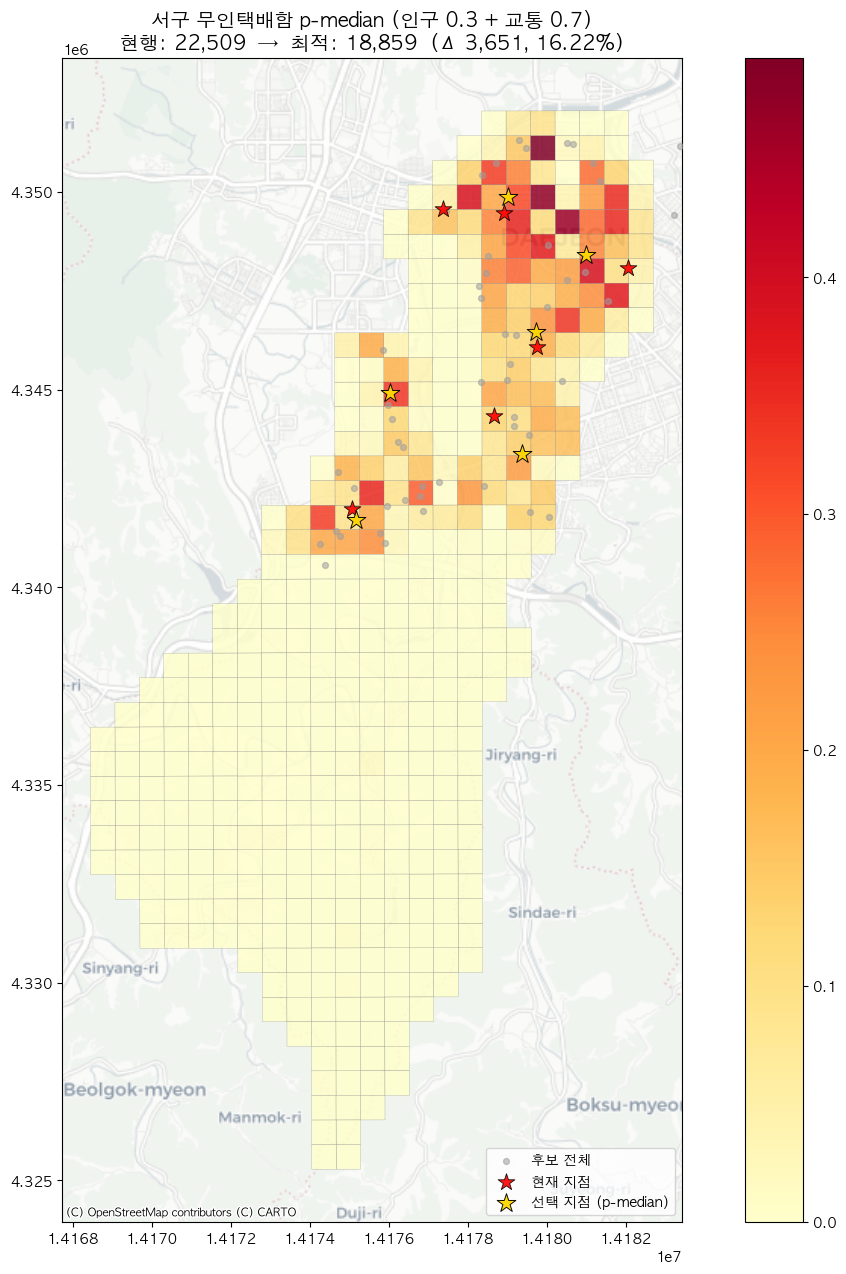

In [19]:
# 가중치: 인구 0.5, 교통(버스+지하철) 0.5
POP_W = 0.3
TRANSIT_W = 0.7

# 최적화 파라미터
TIME_LIMIT = 300   # 초
MIP_GAP    = 0.01  # 1%

# ======================================================
# 2) 데이터 로드 & 수요 w_i 구성
# ======================================================
print("[INFO] Load Seogu grid ...")
gdf = gpd.read_file(input_shp)
gdf = gdf[gdf.geometry.notnull() & gdf.geometry.is_valid].copy()
if (not gdf.crs) or (not gdf.crs.is_projected):
    gdf = gdf.to_crs(5179)  # GRS80 / UTM-K (m 단위 근사)

# 인구 컬럼: 'val' 가정
pop_col = "val"
if pop_col not in gdf.columns:
    raise ValueError(f"'val' 컬럼이 필요합니다. 현재 컬럼: {list(gdf.columns)}")
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce").fillna(0)

print("[INFO] Load transit points (bus/subway) ...")
df_pts = pd.read_csv(csv_path)
df_pts = df_pts[df_pts["시군구명"].str.contains("서구", na=False)].copy()
gdf_pts = gpd.GeoDataFrame(
    df_pts, geometry=gpd.points_from_xy(df_pts["경도"], df_pts["위도"]), crs=4326
).to_crs(5179)

# 격자별 버스/지하철 평균 이용량 집계
joined = gpd.sjoin(gdf_pts, gdf, how="left", predicate="intersects")
joined["월 평균 승하차 인원"] = pd.to_numeric(joined["월 평균 승하차 인원"], errors="coerce").fillna(0)

bus_mean = joined[joined["시설 종류"]=="버스"]   .groupby("index_right")["월 평균 승하차 인원"].mean()
sub_mean = joined[joined["시설 종류"]=="지하철"].groupby("index_right")["월 평균 승하차 인원"].mean()

gdf["bus_mean"] = gdf.index.map(bus_mean).fillna(0)
gdf["sub_mean"] = gdf.index.map(sub_mean).fillna(0)

# Min-Max 정규화
def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    vmin, vmax = s.min(), s.max()
    if vmax - vmin < 1e-12:
        return pd.Series(0.0, index=s.index)
    return (s - vmin) / (vmax - vmin)

# 정규화 및 w_i 계산: w = 0.7*pop_n + 0.3*transit_n (transit = bus/sub 평균)
gdf["pop_n"]     = minmax(gdf[pop_col])
gdf["bus_n"]     = minmax(gdf["bus_mean"])
gdf["sub_n"]     = minmax(gdf["sub_mean"])
gdf["transit_n"] = 0.5*(gdf["bus_n"] + gdf["sub_n"])
gdf["w"]         = POP_W*gdf["pop_n"] + TRANSIT_W*gdf["transit_n"]

# 수요점 = 격자 중심
gdf_cent = gdf.copy()
gdf_cent["geometry"] = gdf_cent.geometry.centroid  # 5179 기준
I = list(range(len(gdf_cent)))

# ======================================================
# 3) 후보 집합 J, p 설정 (현재 개수 유지, 새 후보만 선택)
# ======================================================
print("[INFO] Load current & candidate lockers ...")
df_cur = pd.read_csv(current_lockers, encoding="utf-8-sig")
gdf_cur = gpd.GeoDataFrame(
    df_cur, geometry=gpd.points_from_xy(df_cur["경도"], df_cur["위도"]), crs=4326
).to_crs(5179)

df_new = pd.read_csv(new_lockers_path, encoding="utf-8-sig")
gdf_cand = gpd.GeoDataFrame(
    df_new, geometry=gpd.points_from_xy(df_new["경도"], df_new["위도"]), crs=4326
).to_crs(5179)

# 설치 개수 p = 현재 지점 수
p = len(gdf_cur)
J = list(range(len(gdf_cand)))
print(f"[INFO] |I|={len(I)}, |J|={len(J)}, p={p}")

# ======================================================
# 4) 거리행렬 (5179: m 근사)
# ======================================================
ci = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])
cj = np.array([(pt.x, pt.y) for pt in gdf_cand.geometry])
dmat = np.sqrt(((ci[:,None,:] - cj[None,:,:])**2).sum(axis=2))  # |I| x |J|

# ======================================================
# 5) p-median 최적화
# ======================================================
print("[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...")
w = gdf_cent["w"].to_dict()

m = gp.Model("p_median_relocation")
x = m.addVars(J, vtype=GRB.BINARY, name="x")                        # 후보 설치 여부
y = m.addVars(((i,j) for i in I for j in J), vtype=GRB.BINARY, name="y")  # i→j 할당

# 설치 개수 고정
m.addConstr(gp.quicksum(x[j] for j in J) == p)
# 각 수요 i는 정확히 1곳에 할당
for i in I:
    m.addConstr(gp.quicksum(y[i,j] for j in J) == 1)
# 설치된 곳에만 할당
for i in I:
    for j in J:
        m.addConstr(y[i,j] <= x[j])

# 목적: Σ_i Σ_j w_i * d_ij * y_ij 최소화
m.setObjective(gp.quicksum(w[i]*dmat[i,j]*y[i,j] for i in I for j in J), GRB.MINIMIZE)

m.Params.OutputFlag = 1
m.Params.TimeLimit  = TIME_LIMIT
m.Params.MIPGap     = MIP_GAP
m.optimize()

open_sites = [j for j in J if x[j].X > 0.5]
assign     = {i: max(J, key=lambda j: y[i,j].X) for i in I}
print(f"[RESULT] Open sites (count={len(open_sites)}): {open_sites}")

# ======================================================
# 6) 목적함수 비교: 현행 vs 최적
# ======================================================
# 현행 설치지 집합(현재 무인택배함)과 최적 설치지(새 후보 중 선택)에 대해
# Σ_i w_i * min_j d(i, j) 값을 각각 계산
print("\n=== 목적함수 비교 (p-median; Σ_i w_i * d(i,시설)) ===")
ci_xy = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])                  # |I| x 2
cj_cur_xy = np.array([(pt.x, pt.y) for pt in gdf_cur.geometry])               # |J_cur| x 2
cj_opt_xy = np.array([(pt.x, pt.y) for pt in gdf_cand.iloc[open_sites].geometry])  # |p| x 2

dmat_cur = np.sqrt(((ci_xy[:,None,:] - cj_cur_xy[None,:,:])**2).sum(axis=2)) if len(cj_cur_xy)>0 else np.zeros((len(ci_xy),1))
dmat_opt = np.sqrt(((ci_xy[:,None,:] - cj_opt_xy[None,:,:])**2).sum(axis=2)) if len(cj_opt_xy)>0 else np.zeros((len(ci_xy),1))

min_d_cur = dmat_cur.min(axis=1) if dmat_cur.shape[1] > 0 else np.zeros(len(ci_xy))
min_d_opt = dmat_opt.min(axis=1) if dmat_opt.shape[1] > 0 else np.zeros(len(ci_xy))

w_vec = gdf_cent["w"].to_numpy()
obj_cur = float(np.dot(w_vec, min_d_cur))
obj_opt = float(np.dot(w_vec, min_d_opt))
improve_abs = obj_cur - obj_opt
improve_pct = (improve_abs / obj_cur * 100.0) if obj_cur > 1e-12 else 0.0

print(f"현행 설치(현재 무인택배함)  : {obj_cur:,.2f}")
print(f"최적 해(새 후보 중 선택)   : {obj_opt:,.2f}")
print(f"차이(현행-최적)            : {improve_abs:,.2f}")
print(f"개선율(%)                  : {improve_pct:,.2f}%")

# ======================================================
# 7) 시각화 & 저장 (서구로 자동 확대)
# ======================================================
print("[INFO] Plot ...")
gdf_3857  = gdf.to_crs(3857)
cand_3857 = gdf_cand.to_crs(3857)
cur_3857  = gdf_cur.to_crs(3857)

fig, ax = plt.subplots(figsize=(13, 13))

# 배경: w 코로플레스 (인구0.7+교통0.3)
gdf_3857.plot(ax=ax, column="w", cmap="YlOrRd", legend=True,
              edgecolor="gray", linewidth=0.2, alpha=0.85)

# 전체 후보(연회색 점)
cand_3857.plot(ax=ax, color="#9e9e9e", markersize=18, alpha=0.55, label="후보 전체", zorder=6)

# 현재 지점(빨간★)
cur_3857.plot(ax=ax, marker="*", color="red", edgecolor="black",
              markersize=160, linewidth=0.6, alpha=0.9, label="현재 지점", zorder=8)

# 선택 지점(금색★)
chosen = cand_3857.iloc[open_sites]
chosen.plot(ax=ax, marker="*", color="gold", edgecolor="black",
            markersize=200, linewidth=0.7, alpha=0.95, label="선택 지점 (p-median)", zorder=9)

# ---- 서구 격자 바운딩박스만으로 축 설정(과도한 확대/축소 방지) ----
xmin, ymin, xmax, ymax = gdf_3857.total_bounds
pad_x = (xmax - xmin) * 0.05  # 5% 여백
pad_y = (ymax - ymin) * 0.05
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# 베이스맵
cx.add_basemap(ax, crs=gdf_3857.crs, source=cx.providers.CartoDB.Positron)

ax.set_title(
    f"서구 무인택배함 p-median (인구 0.3 + 교통 0.7)\n"
    f"현행: {obj_cur:,.0f}  →  최적: {obj_opt:,.0f}  (Δ {improve_abs:,.0f}, {improve_pct:,.2f}%)",
    fontsize=14, fontweight="bold"
)
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("seogu_pmedian_pop0p7_transit0p3.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# ======================================================
# Folium: 선택된 "새 후보"만 표시 (OpenStreetMap, 시설명 항상 표시)
# ======================================================
import folium
from IPython.display import display

# 1) 선택된 후보만 추출 → WGS84로 변환
chosen_wgs84 = gdf_cand.iloc[open_sites].to_crs(4326).copy()

# 2) 시설명 컬럼 자동 감지
def pick_name(df):
    for c in ["시설명", "장소", "name", "Name"]:
        if c in df.columns:
            return c
    return None
name_col = pick_name(chosen_wgs84)

# 3) 지도 생성 (OpenStreetMap)
m = folium.Map(location=[37.58, 127.0], tiles="openstreetmap", zoom_start=11)

# 4) 마커 + 이름 라벨 표시
for idx, row in chosen_wgs84.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    lat, lon = row.geometry.y, row.geometry.x
    nm = str(row[name_col]) if name_col and pd.notna(row[name_col]) else f"선택지점 #{idx}"
    
    # 마커 (기본 파란 핀)
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color="blue", icon="info-sign"),
        popup=f"<b>{nm}</b>"
    ).add_to(m)
    
    # 마커 옆 라벨 (DivIcon)
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 11pt;
                color: black;
                background-color: rgba(255,255,255,0.8);
                border-radius: 4px;
                padding: 2px 4px;
                white-space: nowrap;
                ">
                {nm}
            </div>
            """
        )
    ).add_to(m)

# 5) (선택) 선택지의 범위로 화면 자동 맞추기
if len(chosen_wgs84) > 0:
    minx, miny, maxx, maxy = chosen_wgs84.total_bounds
    m.fit_bounds([[miny, minx], [maxy, maxx]])    

# 5) 보기 및 저장
display(m)

<center>

# 대덕구 인구수 7 : 유동인구 3 가중치

</center>

[INFO] Load Seogu grid ...
[INFO] Load transit points (bus/subway) ...
[INFO] Load current & candidate lockers ...
[INFO] |I|=343, |J|=101, p=4
[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
MIPGap  0.01

Optimize a model with 34987 rows, 34744 columns and 104030 nonzeros
Model fingerprint: 0xafe34b8b
Variable types: 0 continuous, 34744 integer (34744 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [4e-01, 1e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+00]
Found heuristic solution: objective 100635.36940
Presolve removed 2 rows and 2 columns
Presolve time: 0.10s
Presolved: 34985 rows, 34742 

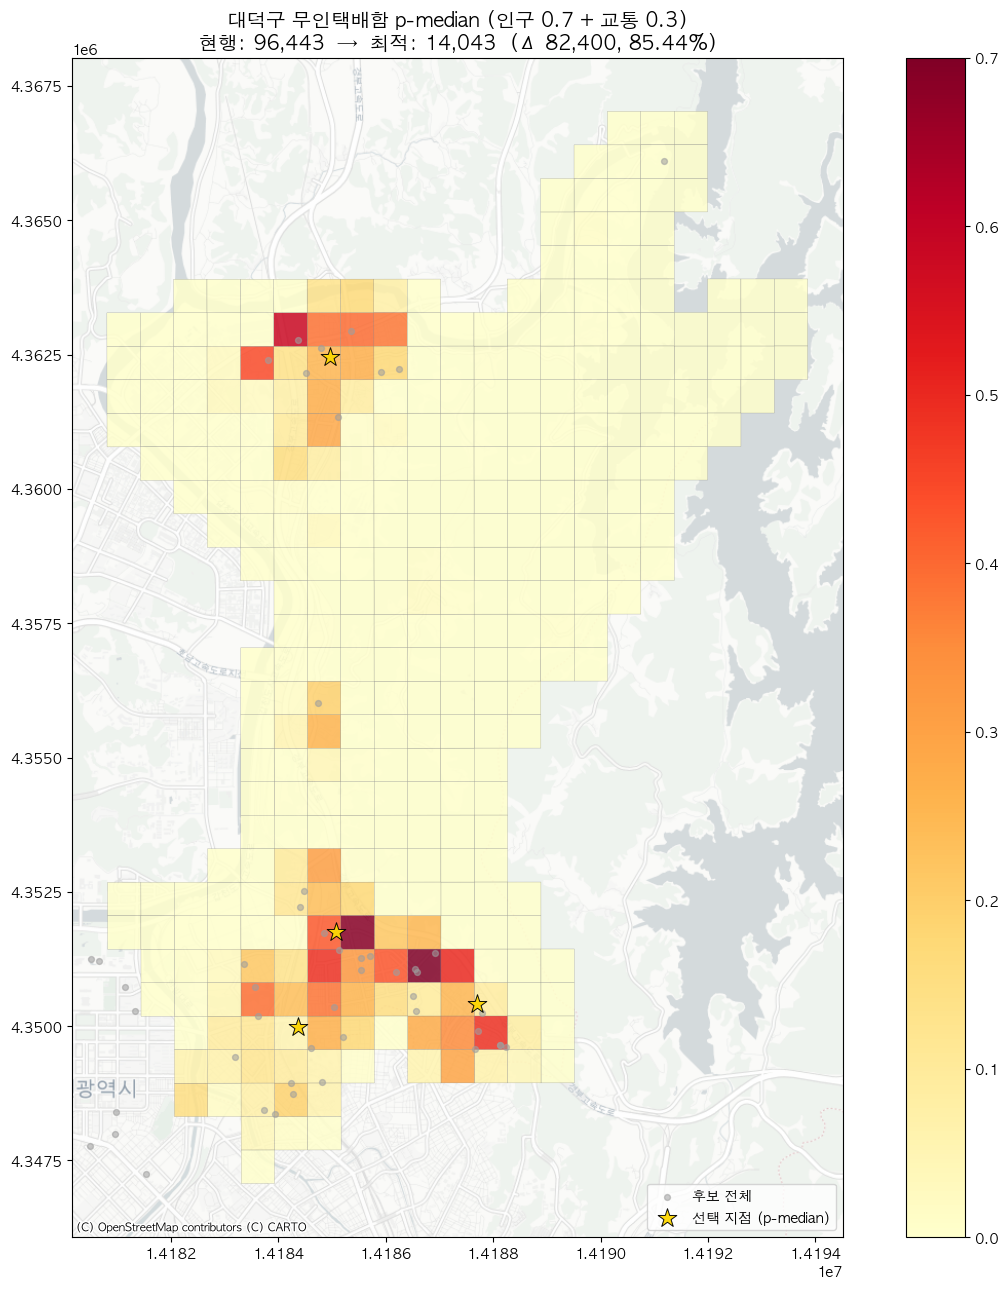

In [6]:

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import gurobipy as gp
from gurobipy import GRB
import warnings
from matplotlib import font_manager, rc

warnings.filterwarnings("ignore", category=UserWarning)

input_shp = r"/Users/anjunho/Desktop/물류 데이터 공모전/인구밀도_대덕구.shp"
csv_path = r"/Users/anjunho/Desktop/물류 데이터 공모전/preprocessing ver7.csv"
current_lockers = r"/Users/anjunho/Desktop/물류 데이터 공모전/무인택배함.csv"
new_lockers_path = r"/Users/anjunho/Desktop/물류 데이터 공모전/finaldestination.csv"

# ===== 한글 폰트 설정 =====
rc('font', family='AppleGothic') # mac 버전/
plt.rcParams['axes.unicode_minus'] = False
#가중치: 인구 0.7, 교통(버스+지하철) 0.3
POP_W = 0.7
TRANSIT_W = 0.3

# 최적화 파라미터
TIME_LIMIT = 300   # 초
MIP_GAP    = 0.01  # 1%

# ======================================================
# 2) 데이터 로드 & 수요 w_i 구성
# ======================================================
print("[INFO] Load Seogu grid ...")
gdf = gpd.read_file(input_shp)
gdf = gdf[gdf.geometry.notnull() & gdf.geometry.is_valid].copy()
if (not gdf.crs) or (not gdf.crs.is_projected):
    gdf = gdf.to_crs(5179)  # GRS80 / UTM-K (m 단위 근사)

# 인구 컬럼: 'val' 가정
pop_col = "val"
if pop_col not in gdf.columns:
    raise ValueError(f"'val' 컬럼이 필요합니다. 현재 컬럼: {list(gdf.columns)}")
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce").fillna(0)

print("[INFO] Load transit points (bus/subway) ...")
df_pts = pd.read_csv(csv_path)
df_pts = df_pts[df_pts["시군구명"].str.contains("서구", na=False)].copy()
gdf_pts = gpd.GeoDataFrame(
    df_pts, geometry=gpd.points_from_xy(df_pts["경도"], df_pts["위도"]), crs=4326
).to_crs(5179)

# 격자별 버스/지하철 평균 이용량 집계
joined = gpd.sjoin(gdf_pts, gdf, how="left", predicate="intersects")
joined["월 평균 승하차 인원"] = pd.to_numeric(joined["월 평균 승하차 인원"], errors="coerce").fillna(0)

bus_mean = joined[joined["시설 종류"]=="버스"]   .groupby("index_right")["월 평균 승하차 인원"].mean()
sub_mean = joined[joined["시설 종류"]=="지하철"].groupby("index_right")["월 평균 승하차 인원"].mean()

gdf["bus_mean"] = gdf.index.map(bus_mean).fillna(0)
gdf["sub_mean"] = gdf.index.map(sub_mean).fillna(0)

# Min-Max 정규화
def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    vmin, vmax = s.min(), s.max()
    if vmax - vmin < 1e-12:
        return pd.Series(0.0, index=s.index)
    return (s - vmin) / (vmax - vmin)

# 정규화 및 w_i 계산: w = 0.7*pop_n + 0.3*transit_n (transit = bus/sub 평균)
gdf["pop_n"]     = minmax(gdf[pop_col])
gdf["bus_n"]     = minmax(gdf["bus_mean"])
gdf["sub_n"]     = minmax(gdf["sub_mean"])
gdf["transit_n"] = 0.5*(gdf["bus_n"] + gdf["sub_n"])
gdf["w"]         = POP_W*gdf["pop_n"] + TRANSIT_W*gdf["transit_n"]

# 수요점 = 격자 중심
gdf_cent = gdf.copy()
gdf_cent["geometry"] = gdf_cent.geometry.centroid  # 5179 기준
I = list(range(len(gdf_cent)))

# ======================================================
# 3) 후보 집합 J, p 설정 (현재 개수 유지, 새 후보만 선택)
# ======================================================
print("[INFO] Load current & candidate lockers ...")
df_cur = pd.read_csv(current_lockers, encoding="utf-8-sig")
gdf_cur = gpd.GeoDataFrame(
    df_cur, geometry=gpd.points_from_xy(df_cur["경도"], df_cur["위도"]), crs=4326
).to_crs(5179)

df_new = pd.read_csv(new_lockers_path, encoding="utf-8-sig")
gdf_cand = gpd.GeoDataFrame(
    df_new, geometry=gpd.points_from_xy(df_new["경도"], df_new["위도"]), crs=4326
).to_crs(5179)

# 설치 개수 p = 현재 지점 수
p = 4
J = list(range(len(gdf_cand)))
print(f"[INFO] |I|={len(I)}, |J|={len(J)}, p={p}")

# ======================================================
# 4) 거리행렬 (5179: m 근사)
# ======================================================
ci = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])
cj = np.array([(pt.x, pt.y) for pt in gdf_cand.geometry])
dmat = np.sqrt(((ci[:,None,:] - cj[None,:,:])**2).sum(axis=2))  # |I| x |J|

# ======================================================
# 5) p-median 최적화
# ======================================================
print("[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...")
w = gdf_cent["w"].to_dict()

m = gp.Model("p_median_relocation")
x = m.addVars(J, vtype=GRB.BINARY, name="x")                        # 후보 설치 여부
y = m.addVars(((i,j) for i in I for j in J), vtype=GRB.BINARY, name="y")  # i→j 할당

# 설치 개수 고정
m.addConstr(gp.quicksum(x[j] for j in J) == p)
# 각 수요 i는 정확히 1곳에 할당
for i in I:
    m.addConstr(gp.quicksum(y[i,j] for j in J) == 1)
# 설치된 곳에만 할당
for i in I:
    for j in J:
        m.addConstr(y[i,j] <= x[j])

# 목적: Σ_i Σ_j w_i * d_ij * y_ij 최소화
m.setObjective(gp.quicksum(w[i]*dmat[i,j]*y[i,j] for i in I for j in J), GRB.MINIMIZE)

m.Params.OutputFlag = 1
m.Params.TimeLimit  = TIME_LIMIT
m.Params.MIPGap     = MIP_GAP
m.optimize()

open_sites = [j for j in J if x[j].X > 0.5]
assign     = {i: max(J, key=lambda j: y[i,j].X) for i in I}
print(f"[RESULT] Open sites (count={len(open_sites)}): {open_sites}")

# ======================================================
# 6) 목적함수 비교: 현행 vs 최적
# ======================================================
# 현행 설치지 집합(현재 무인택배함)과 최적 설치지(새 후보 중 선택)에 대해
# Σ_i w_i * min_j d(i, j) 값을 각각 계산
print("\n=== 목적함수 (p-median; Σ_i w_i * d(i,시설)) ===")
ci_xy = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])                  # |I| x 2
cj_cur_xy = np.array([(pt.x, pt.y) for pt in gdf_cur.geometry])               # |J_cur| x 2
cj_opt_xy = np.array([(pt.x, pt.y) for pt in gdf_cand.iloc[open_sites].geometry])  # |p| x 2

dmat_cur = np.sqrt(((ci_xy[:,None,:] - cj_cur_xy[None,:,:])**2).sum(axis=2)) if len(cj_cur_xy)>0 else np.zeros((len(ci_xy),1))
dmat_opt = np.sqrt(((ci_xy[:,None,:] - cj_opt_xy[None,:,:])**2).sum(axis=2)) if len(cj_opt_xy)>0 else np.zeros((len(ci_xy),1))

min_d_cur = dmat_cur.min(axis=1) if dmat_cur.shape[1] > 0 else np.zeros(len(ci_xy))
min_d_opt = dmat_opt.min(axis=1) if dmat_opt.shape[1] > 0 else np.zeros(len(ci_xy))

w_vec = gdf_cent["w"].to_numpy()
obj_cur = float(np.dot(w_vec, min_d_cur))
obj_opt = float(np.dot(w_vec, min_d_opt))
improve_abs = obj_cur - obj_opt
improve_pct = (improve_abs / obj_cur * 100.0) if obj_cur > 1e-12 else 0.0


print(f"최적 해(새 후보 중 선택)   : {obj_opt:,.2f}")


# ======================================================
# 7) 시각화 & 저장 (서구로 자동 확대)
# ======================================================
print("[INFO] Plot ...")
gdf_3857  = gdf.to_crs(3857)
cand_3857 = gdf_cand.to_crs(3857)
cur_3857  = gdf_cur.to_crs(3857)

fig, ax = plt.subplots(figsize=(13, 13))

# 배경: w 코로플레스 (인구0.7+교통0.3)
gdf_3857.plot(ax=ax, column="w", cmap="YlOrRd", legend=True,
              edgecolor="gray", linewidth=0.2, alpha=0.85)

# 전체 후보(연회색 점)
cand_3857.plot(ax=ax, color="#9e9e9e", markersize=18, alpha=0.55, label="후보 전체", zorder=6)



# 선택 지점(금색★)
chosen = cand_3857.iloc[open_sites]
chosen.plot(ax=ax, marker="*", color="gold", edgecolor="black",
            markersize=200, linewidth=0.7, alpha=0.95, label="선택 지점 (p-median)", zorder=9)

# ---- 서구 격자 바운딩박스만으로 축 설정(과도한 확대/축소 방지) ----
xmin, ymin, xmax, ymax = gdf_3857.total_bounds
pad_x = (xmax - xmin) * 0.05  # 5% 여백
pad_y = (ymax - ymin) * 0.05
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# 베이스맵
cx.add_basemap(ax, crs=gdf_3857.crs, source=cx.providers.CartoDB.Positron)

ax.set_title(
    f"대덕구 무인택배함 p-median (인구 0.7 + 교통 0.3)\n"
    f"현행: {obj_cur:,.0f}  →  최적: {obj_opt:,.0f}  (Δ {improve_abs:,.0f}, {improve_pct:,.2f}%)",
    fontsize=14, fontweight="bold"
)
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("seogu_pmedian_pop0p7_transit0p3.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# ======================================================
# Folium: 선택된 "새 후보"만 표시 (OpenStreetMap, 시설명 항상 표시)
# ======================================================
import folium
from IPython.display import display

# 1) 선택된 후보만 추출 → WGS84로 변환
chosen_wgs84 = gdf_cand.iloc[open_sites].to_crs(4326).copy()

# 2) 시설명 컬럼 자동 감지
def pick_name(df):
    for c in ["시설명", "장소", "name", "Name"]:
        if c in df.columns:
            return c
    return None
name_col = pick_name(chosen_wgs84)

# 3) 지도 생성 (OpenStreetMap)
m = folium.Map(location=[37.58, 127.0], tiles="openstreetmap", zoom_start=11)

# 4) 마커 + 이름 라벨 표시
for idx, row in chosen_wgs84.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    lat, lon = row.geometry.y, row.geometry.x
    nm = str(row[name_col]) if name_col and pd.notna(row[name_col]) else f"선택지점 #{idx}"
    
    # 마커 (기본 파란 핀)
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color="blue", icon="info-sign"),
        popup=f"<b>{nm}</b>"
    ).add_to(m)
    
    # 마커 옆 라벨 (DivIcon)
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 11pt;
                color: black;
                background-color: rgba(255,255,255,0.8);
                border-radius: 4px;
                padding: 2px 4px;
                white-space: nowrap;
                ">
                {nm}
            </div>
            """
        )
    ).add_to(m)

# 5) (선택) 선택지의 범위로 화면 자동 맞추기
if len(chosen_wgs84) > 0:
    minx, miny, maxx, maxy = chosen_wgs84.total_bounds
    m.fit_bounds([[miny, minx], [maxy, maxx]])    

# 5) 보기 및 저장
display(m)

<center>

# 대덕구 인구수 5 : 유동인구 5 가중치

</center>

[INFO] Load Seogu grid ...
[INFO] Load transit points (bus/subway) ...
[INFO] Load current & candidate lockers ...
[INFO] |I|=343, |J|=101, p=4
[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
MIPGap  0.01

Optimize a model with 34987 rows, 34744 columns and 104030 nonzeros
Model fingerprint: 0x77480328
Variable types: 0 continuous, 34744 integer (34744 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e-01, 7e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+00]
Found heuristic solution: objective 72755.108376
Presolve removed 2 rows and 2 columns
Presolve time: 0.10s
Presolved: 34985 rows, 34742 

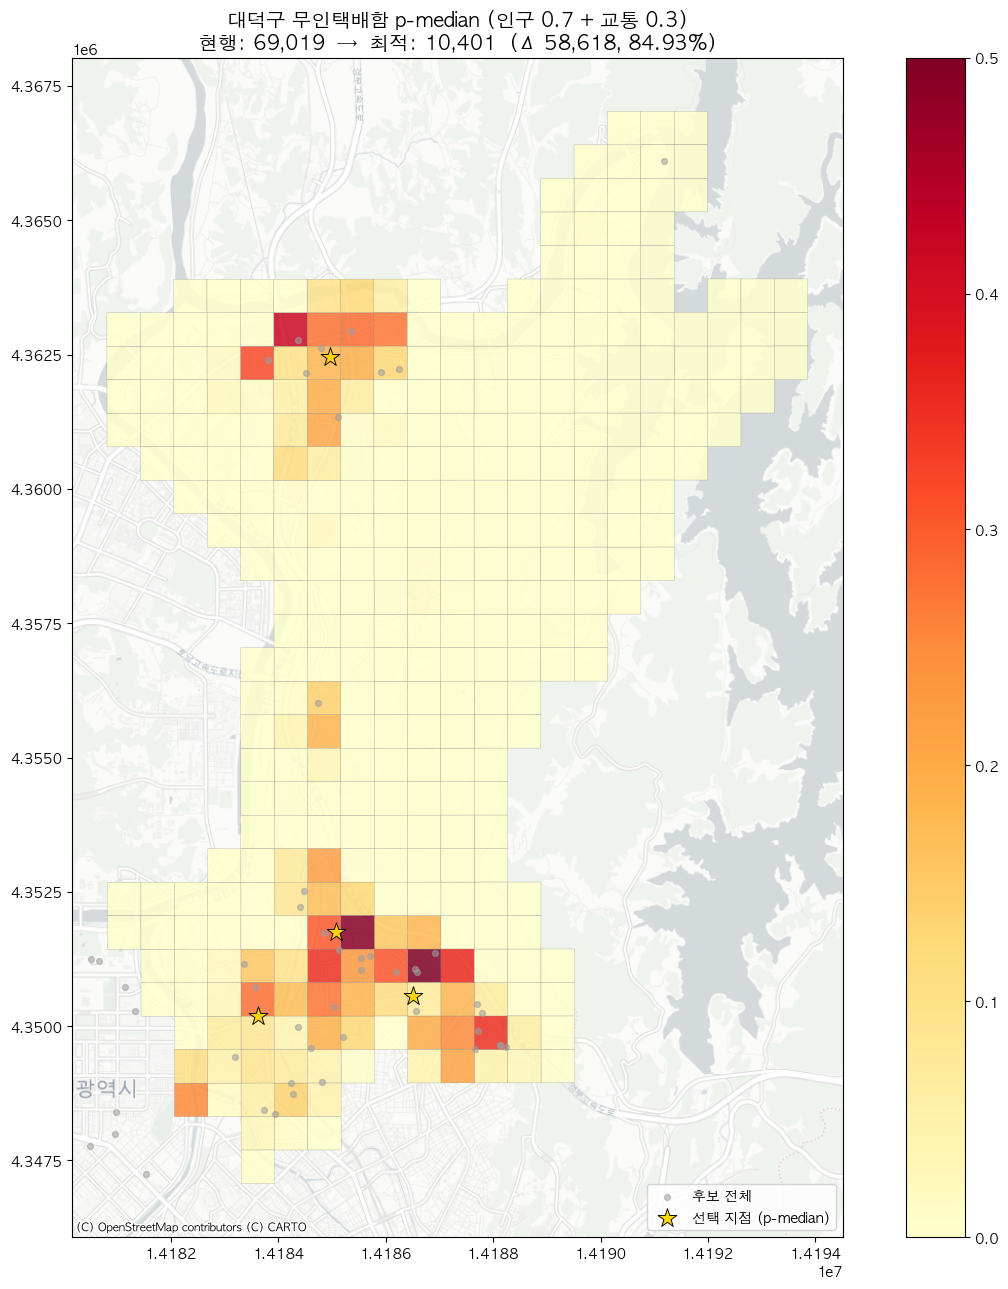

In [21]:

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import gurobipy as gp
from gurobipy import GRB
import warnings
from matplotlib import font_manager, rc

warnings.filterwarnings("ignore", category=UserWarning)

input_shp = r"/Users/anjunho/Desktop/물류 데이터 공모전/인구밀도_대덕구.shp"
csv_path = r"/Users/anjunho/Desktop/물류 데이터 공모전/preprocessing ver7.csv"
current_lockers = r"/Users/anjunho/Desktop/물류 데이터 공모전/무인택배함.csv"
new_lockers_path = r"/Users/anjunho/Desktop/물류 데이터 공모전/finaldestination.csv"

# ===== 한글 폰트 설정 =====
rc('font', family='AppleGothic') # mac 버전/
plt.rcParams['axes.unicode_minus'] = False
#가중치: 인구 0.7, 교통(버스+지하철) 0.3
POP_W = 0.5
TRANSIT_W = 0.5

# 최적화 파라미터
TIME_LIMIT = 300   # 초
MIP_GAP    = 0.01  # 1%

# ======================================================
# 2) 데이터 로드 & 수요 w_i 구성
# ======================================================
print("[INFO] Load Seogu grid ...")
gdf = gpd.read_file(input_shp)
gdf = gdf[gdf.geometry.notnull() & gdf.geometry.is_valid].copy()
if (not gdf.crs) or (not gdf.crs.is_projected):
    gdf = gdf.to_crs(5179)  # GRS80 / UTM-K (m 단위 근사)

# 인구 컬럼: 'val' 가정
pop_col = "val"
if pop_col not in gdf.columns:
    raise ValueError(f"'val' 컬럼이 필요합니다. 현재 컬럼: {list(gdf.columns)}")
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce").fillna(0)

print("[INFO] Load transit points (bus/subway) ...")
df_pts = pd.read_csv(csv_path)
df_pts = df_pts[df_pts["시군구명"].str.contains("서구", na=False)].copy()
gdf_pts = gpd.GeoDataFrame(
    df_pts, geometry=gpd.points_from_xy(df_pts["경도"], df_pts["위도"]), crs=4326
).to_crs(5179)

# 격자별 버스/지하철 평균 이용량 집계
joined = gpd.sjoin(gdf_pts, gdf, how="left", predicate="intersects")
joined["월 평균 승하차 인원"] = pd.to_numeric(joined["월 평균 승하차 인원"], errors="coerce").fillna(0)

bus_mean = joined[joined["시설 종류"]=="버스"]   .groupby("index_right")["월 평균 승하차 인원"].mean()
sub_mean = joined[joined["시설 종류"]=="지하철"].groupby("index_right")["월 평균 승하차 인원"].mean()

gdf["bus_mean"] = gdf.index.map(bus_mean).fillna(0)
gdf["sub_mean"] = gdf.index.map(sub_mean).fillna(0)

# Min-Max 정규화
def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    vmin, vmax = s.min(), s.max()
    if vmax - vmin < 1e-12:
        return pd.Series(0.0, index=s.index)
    return (s - vmin) / (vmax - vmin)

# 정규화 및 w_i 계산: w = 0.7*pop_n + 0.3*transit_n (transit = bus/sub 평균)
gdf["pop_n"]     = minmax(gdf[pop_col])
gdf["bus_n"]     = minmax(gdf["bus_mean"])
gdf["sub_n"]     = minmax(gdf["sub_mean"])
gdf["transit_n"] = 0.5*(gdf["bus_n"] + gdf["sub_n"])
gdf["w"]         = POP_W*gdf["pop_n"] + TRANSIT_W*gdf["transit_n"]

# 수요점 = 격자 중심
gdf_cent = gdf.copy()
gdf_cent["geometry"] = gdf_cent.geometry.centroid  # 5179 기준
I = list(range(len(gdf_cent)))

# ======================================================
# 3) 후보 집합 J, p 설정 (현재 개수 유지, 새 후보만 선택)
# ======================================================
print("[INFO] Load current & candidate lockers ...")
df_cur = pd.read_csv(current_lockers, encoding="utf-8-sig")
gdf_cur = gpd.GeoDataFrame(
    df_cur, geometry=gpd.points_from_xy(df_cur["경도"], df_cur["위도"]), crs=4326
).to_crs(5179)

df_new = pd.read_csv(new_lockers_path, encoding="utf-8-sig")
gdf_cand = gpd.GeoDataFrame(
    df_new, geometry=gpd.points_from_xy(df_new["경도"], df_new["위도"]), crs=4326
).to_crs(5179)

# 설치 개수 p = 현재 지점 수
p = 4
J = list(range(len(gdf_cand)))
print(f"[INFO] |I|={len(I)}, |J|={len(J)}, p={p}")

# ======================================================
# 4) 거리행렬 (5179: m 근사)
# ======================================================
ci = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])
cj = np.array([(pt.x, pt.y) for pt in gdf_cand.geometry])
dmat = np.sqrt(((ci[:,None,:] - cj[None,:,:])**2).sum(axis=2))  # |I| x |J|

# ======================================================
# 5) p-median 최적화
# ======================================================
print("[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...")
w = gdf_cent["w"].to_dict()

m = gp.Model("p_median_relocation")
x = m.addVars(J, vtype=GRB.BINARY, name="x")                        # 후보 설치 여부
y = m.addVars(((i,j) for i in I for j in J), vtype=GRB.BINARY, name="y")  # i→j 할당

# 설치 개수 고정
m.addConstr(gp.quicksum(x[j] for j in J) == p)
# 각 수요 i는 정확히 1곳에 할당
for i in I:
    m.addConstr(gp.quicksum(y[i,j] for j in J) == 1)
# 설치된 곳에만 할당
for i in I:
    for j in J:
        m.addConstr(y[i,j] <= x[j])

# 목적: Σ_i Σ_j w_i * d_ij * y_ij 최소화
m.setObjective(gp.quicksum(w[i]*dmat[i,j]*y[i,j] for i in I for j in J), GRB.MINIMIZE)

m.Params.OutputFlag = 1
m.Params.TimeLimit  = TIME_LIMIT
m.Params.MIPGap     = MIP_GAP
m.optimize()

open_sites = [j for j in J if x[j].X > 0.5]
assign     = {i: max(J, key=lambda j: y[i,j].X) for i in I}
print(f"[RESULT] Open sites (count={len(open_sites)}): {open_sites}")

# ======================================================
# 6) 목적함수 비교: 현행 vs 최적
# ======================================================
# 현행 설치지 집합(현재 무인택배함)과 최적 설치지(새 후보 중 선택)에 대해
# Σ_i w_i * min_j d(i, j) 값을 각각 계산
print("\n=== 목적함수 (p-median; Σ_i w_i * d(i,시설)) ===")
ci_xy = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])                  # |I| x 2
cj_cur_xy = np.array([(pt.x, pt.y) for pt in gdf_cur.geometry])               # |J_cur| x 2
cj_opt_xy = np.array([(pt.x, pt.y) for pt in gdf_cand.iloc[open_sites].geometry])  # |p| x 2

dmat_cur = np.sqrt(((ci_xy[:,None,:] - cj_cur_xy[None,:,:])**2).sum(axis=2)) if len(cj_cur_xy)>0 else np.zeros((len(ci_xy),1))
dmat_opt = np.sqrt(((ci_xy[:,None,:] - cj_opt_xy[None,:,:])**2).sum(axis=2)) if len(cj_opt_xy)>0 else np.zeros((len(ci_xy),1))

min_d_cur = dmat_cur.min(axis=1) if dmat_cur.shape[1] > 0 else np.zeros(len(ci_xy))
min_d_opt = dmat_opt.min(axis=1) if dmat_opt.shape[1] > 0 else np.zeros(len(ci_xy))

w_vec = gdf_cent["w"].to_numpy()
obj_cur = float(np.dot(w_vec, min_d_cur))
obj_opt = float(np.dot(w_vec, min_d_opt))
improve_abs = obj_cur - obj_opt
improve_pct = (improve_abs / obj_cur * 100.0) if obj_cur > 1e-12 else 0.0


print(f"최적 해(새 후보 중 선택)   : {obj_opt:,.2f}")


# ======================================================
# 7) 시각화 & 저장 (서구로 자동 확대)
# ======================================================
print("[INFO] Plot ...")
gdf_3857  = gdf.to_crs(3857)
cand_3857 = gdf_cand.to_crs(3857)
cur_3857  = gdf_cur.to_crs(3857)

fig, ax = plt.subplots(figsize=(13, 13))

# 배경: w 코로플레스 (인구0.7+교통0.3)
gdf_3857.plot(ax=ax, column="w", cmap="YlOrRd", legend=True,
              edgecolor="gray", linewidth=0.2, alpha=0.85)

# 전체 후보(연회색 점)
cand_3857.plot(ax=ax, color="#9e9e9e", markersize=18, alpha=0.55, label="후보 전체", zorder=6)



# 선택 지점(금색★)
chosen = cand_3857.iloc[open_sites]
chosen.plot(ax=ax, marker="*", color="gold", edgecolor="black",
            markersize=200, linewidth=0.7, alpha=0.95, label="선택 지점 (p-median)", zorder=9)

# ---- 서구 격자 바운딩박스만으로 축 설정(과도한 확대/축소 방지) ----
xmin, ymin, xmax, ymax = gdf_3857.total_bounds
pad_x = (xmax - xmin) * 0.05  # 5% 여백
pad_y = (ymax - ymin) * 0.05
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# 베이스맵
cx.add_basemap(ax, crs=gdf_3857.crs, source=cx.providers.CartoDB.Positron)

ax.set_title(
    f"대덕구 무인택배함 p-median (인구 0.7 + 교통 0.3)\n"
    f"현행: {obj_cur:,.0f}  →  최적: {obj_opt:,.0f}  (Δ {improve_abs:,.0f}, {improve_pct:,.2f}%)",
    fontsize=14, fontweight="bold"
)
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("seogu_pmedian_pop0p7_transit0p3.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# ======================================================
# Folium: 선택된 "새 후보"만 표시 (OpenStreetMap, 시설명 항상 표시)
# ======================================================
import folium
from IPython.display import display

# 1) 선택된 후보만 추출 → WGS84로 변환
chosen_wgs84 = gdf_cand.iloc[open_sites].to_crs(4326).copy()

# 2) 시설명 컬럼 자동 감지
def pick_name(df):
    for c in ["시설명", "장소", "name", "Name"]:
        if c in df.columns:
            return c
    return None
name_col = pick_name(chosen_wgs84)

# 3) 지도 생성 (OpenStreetMap)
m = folium.Map(location=[37.58, 127.0], tiles="openstreetmap", zoom_start=11)

# 4) 마커 + 이름 라벨 표시
for idx, row in chosen_wgs84.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    lat, lon = row.geometry.y, row.geometry.x
    nm = str(row[name_col]) if name_col and pd.notna(row[name_col]) else f"선택지점 #{idx}"
    
    # 마커 (기본 파란 핀)
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color="blue", icon="info-sign"),
        popup=f"<b>{nm}</b>"
    ).add_to(m)
    
    # 마커 옆 라벨 (DivIcon)
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 11pt;
                color: black;
                background-color: rgba(255,255,255,0.8);
                border-radius: 4px;
                padding: 2px 4px;
                white-space: nowrap;
                ">
                {nm}
            </div>
            """
        )
    ).add_to(m)

# 5) (선택) 선택지의 범위로 화면 자동 맞추기
if len(chosen_wgs84) > 0:
    minx, miny, maxx, maxy = chosen_wgs84.total_bounds
    m.fit_bounds([[miny, minx], [maxy, maxx]])    

# 5) 보기 및 저장
display(m)

<center>

# 대덕구 인구수 3 : 유동인구 7 가중치

</center>

[INFO] Load Seogu grid ...
[INFO] Load transit points (bus/subway) ...
[INFO] Load current & candidate lockers ...
[INFO] |I|=343, |J|=101, p=4
[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.0.0 25A362)

CPU model: Apple M1 Pro
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
MIPGap  0.01

Optimize a model with 34987 rows, 34744 columns and 104030 nonzeros
Model fingerprint: 0x27630e70
Variable types: 0 continuous, 34744 integer (34744 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e-01, 5e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+00]
Found heuristic solution: objective 44874.847356
Presolve removed 1 rows and 1 columns
Presolve time: 0.10s
Presolved: 34986 rows, 34743 

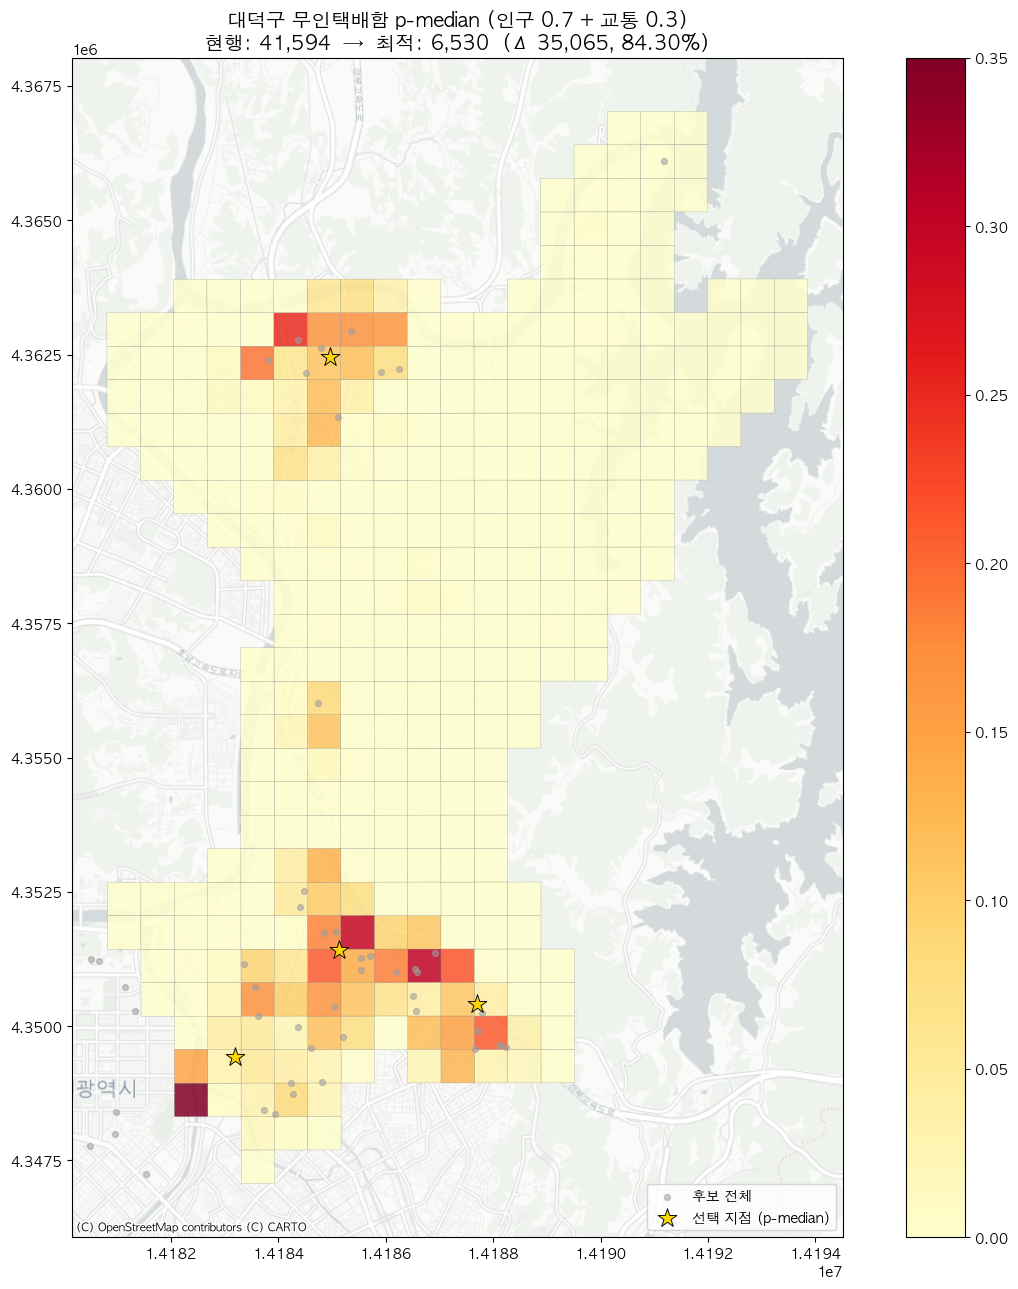

In [25]:

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import gurobipy as gp
from gurobipy import GRB
import warnings
from matplotlib import font_manager, rc

warnings.filterwarnings("ignore", category=UserWarning)

input_shp = r"/Users/anjunho/Desktop/물류 데이터 공모전/인구밀도_대덕구.shp"
csv_path = r"/Users/anjunho/Desktop/물류 데이터 공모전/preprocessing ver7.csv"
current_lockers = r"/Users/anjunho/Desktop/물류 데이터 공모전/무인택배함.csv"
new_lockers_path = r"/Users/anjunho/Desktop/물류 데이터 공모전/finaldestination.csv"

# ===== 한글 폰트 설정 =====
rc('font', family='AppleGothic') # mac 버전/
plt.rcParams['axes.unicode_minus'] = False
#가중치: 인구 0.7, 교통(버스+지하철) 0.3
POP_W = 0.3
TRANSIT_W = 0.7

# 최적화 파라미터
TIME_LIMIT = 300   # 초
MIP_GAP    = 0.01  # 1%

# ======================================================
# 2) 데이터 로드 & 수요 w_i 구성
# ======================================================
print("[INFO] Load Seogu grid ...")
gdf = gpd.read_file(input_shp)
gdf = gdf[gdf.geometry.notnull() & gdf.geometry.is_valid].copy()
if (not gdf.crs) or (not gdf.crs.is_projected):
    gdf = gdf.to_crs(5179)  # GRS80 / UTM-K (m 단위 근사)

# 인구 컬럼: 'val' 가정
pop_col = "val"
if pop_col not in gdf.columns:
    raise ValueError(f"'val' 컬럼이 필요합니다. 현재 컬럼: {list(gdf.columns)}")
gdf[pop_col] = pd.to_numeric(gdf[pop_col], errors="coerce").fillna(0)

print("[INFO] Load transit points (bus/subway) ...")
df_pts = pd.read_csv(csv_path)
df_pts = df_pts[df_pts["시군구명"].str.contains("서구", na=False)].copy()
gdf_pts = gpd.GeoDataFrame(
    df_pts, geometry=gpd.points_from_xy(df_pts["경도"], df_pts["위도"]), crs=4326
).to_crs(5179)

# 격자별 버스/지하철 평균 이용량 집계
joined = gpd.sjoin(gdf_pts, gdf, how="left", predicate="intersects")
joined["월 평균 승하차 인원"] = pd.to_numeric(joined["월 평균 승하차 인원"], errors="coerce").fillna(0)

bus_mean = joined[joined["시설 종류"]=="버스"]   .groupby("index_right")["월 평균 승하차 인원"].mean()
sub_mean = joined[joined["시설 종류"]=="지하철"].groupby("index_right")["월 평균 승하차 인원"].mean()

gdf["bus_mean"] = gdf.index.map(bus_mean).fillna(0)
gdf["sub_mean"] = gdf.index.map(sub_mean).fillna(0)

# Min-Max 정규화
def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    vmin, vmax = s.min(), s.max()
    if vmax - vmin < 1e-12:
        return pd.Series(0.0, index=s.index)
    return (s - vmin) / (vmax - vmin)

# 정규화 및 w_i 계산: w = 0.7*pop_n + 0.3*transit_n (transit = bus/sub 평균)
gdf["pop_n"]     = minmax(gdf[pop_col])
gdf["bus_n"]     = minmax(gdf["bus_mean"])
gdf["sub_n"]     = minmax(gdf["sub_mean"])
gdf["transit_n"] = 0.5*(gdf["bus_n"] + gdf["sub_n"])
gdf["w"]         = POP_W*gdf["pop_n"] + TRANSIT_W*gdf["transit_n"]

# 수요점 = 격자 중심
gdf_cent = gdf.copy()
gdf_cent["geometry"] = gdf_cent.geometry.centroid  # 5179 기준
I = list(range(len(gdf_cent)))

# ======================================================
# 3) 후보 집합 J, p 설정 (현재 개수 유지, 새 후보만 선택)
# ======================================================
print("[INFO] Load current & candidate lockers ...")
df_cur = pd.read_csv(current_lockers, encoding="utf-8-sig")
gdf_cur = gpd.GeoDataFrame(
    df_cur, geometry=gpd.points_from_xy(df_cur["경도"], df_cur["위도"]), crs=4326
).to_crs(5179)

df_new = pd.read_csv(new_lockers_path, encoding="utf-8-sig")
gdf_cand = gpd.GeoDataFrame(
    df_new, geometry=gpd.points_from_xy(df_new["경도"], df_new["위도"]), crs=4326
).to_crs(5179)

# 설치 개수 p = 현재 지점 수
p = 4
J = list(range(len(gdf_cand)))
print(f"[INFO] |I|={len(I)}, |J|={len(J)}, p={p}")

# ======================================================
# 4) 거리행렬 (5179: m 근사)
# ======================================================
ci = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])
cj = np.array([(pt.x, pt.y) for pt in gdf_cand.geometry])
dmat = np.sqrt(((ci[:,None,:] - cj[None,:,:])**2).sum(axis=2))  # |I| x |J|

# ======================================================
# 5) p-median 최적화
# ======================================================
print("[INFO] Solve p-median (w = 0.7*pop + 0.3*transit) ...")
w = gdf_cent["w"].to_dict()

m = gp.Model("p_median_relocation")
x = m.addVars(J, vtype=GRB.BINARY, name="x")                        # 후보 설치 여부
y = m.addVars(((i,j) for i in I for j in J), vtype=GRB.BINARY, name="y")  # i→j 할당

# 설치 개수 고정
m.addConstr(gp.quicksum(x[j] for j in J) == p)
# 각 수요 i는 정확히 1곳에 할당
for i in I:
    m.addConstr(gp.quicksum(y[i,j] for j in J) == 1)
# 설치된 곳에만 할당
for i in I:
    for j in J:
        m.addConstr(y[i,j] <= x[j])

# 목적: Σ_i Σ_j w_i * d_ij * y_ij 최소화
m.setObjective(gp.quicksum(w[i]*dmat[i,j]*y[i,j] for i in I for j in J), GRB.MINIMIZE)

m.Params.OutputFlag = 1
m.Params.TimeLimit  = TIME_LIMIT
m.Params.MIPGap     = MIP_GAP
m.optimize()

open_sites = [j for j in J if x[j].X > 0.5]
assign     = {i: max(J, key=lambda j: y[i,j].X) for i in I}
print(f"[RESULT] Open sites (count={len(open_sites)}): {open_sites}")

# ======================================================
# 6) 목적함수 비교: 현행 vs 최적
# ======================================================
# 현행 설치지 집합(현재 무인택배함)과 최적 설치지(새 후보 중 선택)에 대해
# Σ_i w_i * min_j d(i, j) 값을 각각 계산
print("\n=== 목적함수 (p-median; Σ_i w_i * d(i,시설)) ===")
ci_xy = np.array([(pt.x, pt.y) for pt in gdf_cent.geometry])                  # |I| x 2
cj_cur_xy = np.array([(pt.x, pt.y) for pt in gdf_cur.geometry])               # |J_cur| x 2
cj_opt_xy = np.array([(pt.x, pt.y) for pt in gdf_cand.iloc[open_sites].geometry])  # |p| x 2

dmat_cur = np.sqrt(((ci_xy[:,None,:] - cj_cur_xy[None,:,:])**2).sum(axis=2)) if len(cj_cur_xy)>0 else np.zeros((len(ci_xy),1))
dmat_opt = np.sqrt(((ci_xy[:,None,:] - cj_opt_xy[None,:,:])**2).sum(axis=2)) if len(cj_opt_xy)>0 else np.zeros((len(ci_xy),1))

min_d_cur = dmat_cur.min(axis=1) if dmat_cur.shape[1] > 0 else np.zeros(len(ci_xy))
min_d_opt = dmat_opt.min(axis=1) if dmat_opt.shape[1] > 0 else np.zeros(len(ci_xy))

w_vec = gdf_cent["w"].to_numpy()
obj_cur = float(np.dot(w_vec, min_d_cur))
obj_opt = float(np.dot(w_vec, min_d_opt))
improve_abs = obj_cur - obj_opt
improve_pct = (improve_abs / obj_cur * 100.0) if obj_cur > 1e-12 else 0.0


print(f"최적 해(새 후보 중 선택)   : {obj_opt:,.2f}")


# ======================================================
# 7) 시각화 & 저장 (서구로 자동 확대)
# ======================================================
print("[INFO] Plot ...")
gdf_3857  = gdf.to_crs(3857)
cand_3857 = gdf_cand.to_crs(3857)
cur_3857  = gdf_cur.to_crs(3857)

fig, ax = plt.subplots(figsize=(13, 13))

# 배경: w 코로플레스 (인구0.7+교통0.3)
gdf_3857.plot(ax=ax, column="w", cmap="YlOrRd", legend=True,
              edgecolor="gray", linewidth=0.2, alpha=0.85)

# 전체 후보(연회색 점)
cand_3857.plot(ax=ax, color="#9e9e9e", markersize=18, alpha=0.55, label="후보 전체", zorder=6)



# 선택 지점(금색★)
chosen = cand_3857.iloc[open_sites]
chosen.plot(ax=ax, marker="*", color="gold", edgecolor="black",
            markersize=200, linewidth=0.7, alpha=0.95, label="선택 지점 (p-median)", zorder=9)

# ---- 서구 격자 바운딩박스만으로 축 설정(과도한 확대/축소 방지) ----
xmin, ymin, xmax, ymax = gdf_3857.total_bounds
pad_x = (xmax - xmin) * 0.05  # 5% 여백
pad_y = (ymax - ymin) * 0.05
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# 베이스맵
cx.add_basemap(ax, crs=gdf_3857.crs, source=cx.providers.CartoDB.Positron)

ax.set_title(
    f"대덕구 무인택배함 p-median (인구 0.7 + 교통 0.3)\n"
    f"현행: {obj_cur:,.0f}  →  최적: {obj_opt:,.0f}  (Δ {improve_abs:,.0f}, {improve_pct:,.2f}%)",
    fontsize=14, fontweight="bold"
)
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("seogu_pmedian_pop0p7_transit0p3.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# ======================================================
# Folium: 선택된 "새 후보"만 표시 (OpenStreetMap, 시설명 항상 표시)
# ======================================================
import folium
from IPython.display import display

# 1) 선택된 후보만 추출 → WGS84로 변환
chosen_wgs84 = gdf_cand.iloc[open_sites].to_crs(4326).copy()

# 2) 시설명 컬럼 자동 감지
def pick_name(df):
    for c in ["시설명", "장소", "name", "Name"]:
        if c in df.columns:
            return c
    return None
name_col = pick_name(chosen_wgs84)

# 3) 지도 생성 (OpenStreetMap)
m = folium.Map(location=[37.58, 127.0], tiles="openstreetmap", zoom_start=11)

# 4) 마커 + 이름 라벨 표시
for idx, row in chosen_wgs84.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    lat, lon = row.geometry.y, row.geometry.x
    nm = str(row[name_col]) if name_col and pd.notna(row[name_col]) else f"선택지점 #{idx}"
    
    # 마커 (기본 파란 핀)
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color="blue", icon="info-sign"),
        popup=f"<b>{nm}</b>"
    ).add_to(m)
    
    # 마커 옆 라벨 (DivIcon)
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 11pt;
                color: black;
                background-color: rgba(255,255,255,0.8);
                border-radius: 4px;
                padding: 2px 4px;
                white-space: nowrap;
                ">
                {nm}
            </div>
            """
        )
    ).add_to(m)

# 5) (선택) 선택지의 범위로 화면 자동 맞추기
if len(chosen_wgs84) > 0:
    minx, miny, maxx, maxy = chosen_wgs84.total_bounds
    m.fit_bounds([[miny, minx], [maxy, maxx]])    

# 5) 보기 및 저장
display(m)